# Dipole Radiation: Two Coupled Radiators

Rebuilt from `legacy/Dipoles.py`, which validated two coupled radiating
dipoles against `pycharge`'s internal `pc.s_dipole_theory` coupling
-constant formula. That formula isn't independently reproduced here (per
`Retarded_Fields_Plan.md`); instead, each charge's own radiation already
follows directly from `retarded_fields.py`'s single universal
Lienard-Wiechert formula -- already validated three independent ways in
`Validation.ipynb` (Coulomb limit, boosted-Coulomb closed form, Larmor
power) regardless of which path function is plugged in, so re-deriving a
Larmor check for this particular oscillation shape would be redundant.
What *is* new and specific to having two charges is **superposition**:
does simply adding the two independently-computed fields reproduce the
correct interference pattern? That's what's validated here, against the
standard two-source array-factor result from antenna theory.

In [1]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
from matplotlib.colors import LogNorm
from numba import njit
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import retarded_fields as rf

os.makedirs('media', exist_ok=True)
c, eps0, q = 1.0, 1.0, 1.0
mu0 = 1 / (eps0 * c**2)

## Two in-phase charges, oscillating along y, separated along x

Each behaves like a tiny linear dipole antenna (oscillating charge <->
oscillating acceleration <-> radiation polarized along the oscillation
axis). With both charges in phase, the far field in a given direction is
the coherent sum of both -- constructive where their path-length
difference is a multiple of a wavelength, destructive where it's a half
-integer multiple (the standard two-element array-factor result).

In [2]:
A = 0.01       # oscillation amplitude
omega = 0.3    # angular frequency
d = 5.0        # separation along x
wavelength = 2 * np.pi * c / omega
print(f'wavelength = {wavelength:.2f}, separation/wavelength = {d/wavelength:.3f}')

def make_charge(x_offset):
    r_func = lambda t: np.array([x_offset, A * np.sin(omega * t), 0.0])
    v_func = lambda t: np.array([0.0, A * omega * np.cos(omega * t), 0.0])
    a_func = lambda t: np.array([0.0, -A * omega**2 * np.sin(omega * t), 0.0])
    return r_func, v_func, a_func

r1, v1, a1 = make_charge(-d / 2)
r2, v2, a2 = make_charge(d / 2)

wavelength = 20.94, separation/wavelength = 0.239


## Quantitative check: far-field interference pattern vs. the array factor

R_obs / wavelength = 95.5 (far field)
correlation between simulated and predicted angular power pattern: 0.9990
PASS: superposing the two independently-computed fields reproduces the correct interference pattern.


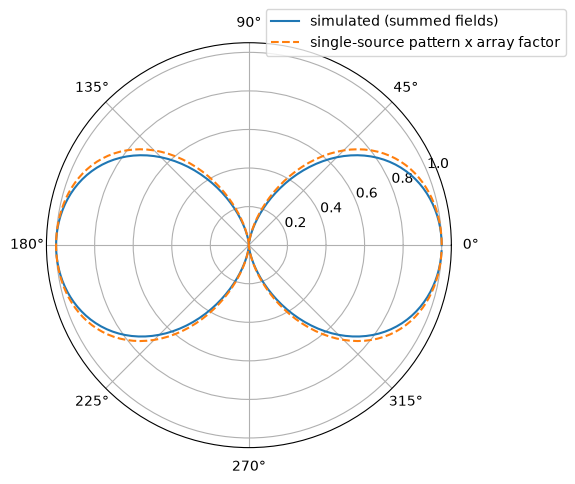

In [3]:
R_obs = 2000.0
print(f'R_obs / wavelength = {R_obs / wavelength:.1f} (far field)')

n_phi = 200
phis = np.linspace(0, 2 * np.pi, n_phi, endpoint=False)
P_total = np.zeros(n_phi)
for k, phi in enumerate(phis):
    x = np.array([R_obs * np.cos(phi), R_obs * np.sin(phi), 0.0])
    E1, B1 = rf.lw_fields(r1, v1, a1, x, 0.0, q, c=c, eps0=eps0)
    E2, B2 = rf.lw_fields(r2, v2, a2, x, 0.0, q, c=c, eps0=eps0)
    E, B = E1 + E2, B1 + B2
    S = np.cross(E, B) / mu0
    n_hat = x / np.linalg.norm(x)
    P_total[k] = np.dot(S, n_hat) * R_obs**2

# analytic prediction (up to overall normalization): single-charge Larmor
# angular dependence (~cos^2(phi), since acceleration is along y and phi is
# measured from x) times the two-source array factor cos^2(k*d*cos(phi)/2)
k_wave = omega / c
single_source_pattern = np.cos(phis)**2
array_factor = np.cos(k_wave * d * np.cos(phis) / 2)**2
predicted = single_source_pattern * array_factor
predicted *= P_total.max() / predicted.max()

corr = np.corrcoef(P_total, predicted)[0, 1]
print(f'correlation between simulated and predicted angular power pattern: {corr:.4f}')
assert corr > 0.99, 'the interference pattern from summed fields does not match the array-factor prediction'
print('PASS: superposing the two independently-computed fields reproduces the correct interference pattern.')

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
ax.plot(phis, P_total / P_total.max(), label='simulated (summed fields)')
ax.plot(phis, predicted / predicted.max(), '--', label='single-source pattern x array factor')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
fig.tight_layout()
fig.savefig('media/dipole_interference_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

## Animation: near-field of both radiators together

The array-factor check above uses parameters chosen to match the standard
weak-radiator dipole-antenna approximation (`A=0.01`, so `v_max=0.003c`) --
deliberately non-relativistic so the analytic comparison is apples-to-apples
with antenna theory. But that also means the *radiation* (far, `1/R`) term is
tiny next to the *quasi-static* (near, `1/R^2`, reducing to plain Coulomb as
`beta->0`) term almost everywhere reasonable to plot: the near/far crossover
radius works out to `c/(A*omega^2) ~ 1100`, far outside any sane near-field
animation window. So a near-field animation at the array-factor parameters
just shows two static-looking Coulomb blobs -- correct, but visually inert
(the interference *is* there, just ~1000x fainter than the static part, at
any distance small enough to plot).

To actually watch the interference pattern propagate, the animation below
uses a second, more strongly-radiating charge pair -- larger amplitude and
frequency, same `retarded_fields.py` solver and same physics (no
re-validation needed, per `Retarded_Fields_Plan.md`) -- so the crossover
radius sits well inside the plotted window and the radiation term dominates
almost everywhere onscreen.

In [4]:
A_anim = 0.6
omega_anim = 1.0
d_anim = 3.0
wavelength_anim = 2 * np.pi * c / omega_anim
r_cross_anim = c / (A_anim * omega_anim**2)  # near/far crossover radius
print(f'animation: wavelength={wavelength_anim:.2f}, v_max={A_anim*omega_anim:.2f}c, '
      f'near/far crossover radius={r_cross_anim:.2f}')

# njit closures (returning plain (x, y, z) tuples, not np.array) -- required
# by rf.lw_fields_grid_jit, the numba-accelerated grid solver used below.
# See the comment above _retarded_time_jit in retarded_fields.py: JIT-
# compiling this inner loop turns a ~200ms/frame grid computation into
# ~0.2ms/frame.
def make_anim_charge(x_offset):
    @njit(cache=True)
    def r_func(t):
        return x_offset, A_anim * math.sin(omega_anim * t), 0.0

    @njit(cache=True)
    def v_func(t):
        return 0.0, A_anim * omega_anim * math.cos(omega_anim * t), 0.0

    @njit(cache=True)
    def a_func(t):
        return 0.0, -A_anim * omega_anim**2 * math.sin(omega_anim * t), 0.0

    return r_func, v_func, a_func

r1_anim, v1_anim, a1_anim = make_anim_charge(-d_anim / 2)
r2_anim, v2_anim, a2_anim = make_anim_charge(d_anim / 2)

animation: wavelength=6.28, v_max=0.60c, near/far crossover radius=1.67


In [5]:
N = 3 * 90
extent = 20.0
xs = np.linspace(-extent, extent, N)
X, Y = np.meshgrid(xs, xs, indexing='ij')
Z = np.zeros_like(X)

T_period = 3 * 2 * np.pi / omega_anim
n_frames = 3 * 60
times = np.linspace(0, T_period, n_frames, endpoint=False)
E_mag_frames = np.zeros((n_frames, N, N))
t_ret_guess1 = None
t_ret_guess2 = None
for i, t in enumerate(times):
    E1, _, t_ret_guess1 = rf.lw_fields_grid_jit(r1_anim, v1_anim, a1_anim, X, Y, Z, t=t, q=q, c=c, eps0=eps0,
                                                 t_ret_guess=t_ret_guess1)
    E2, _, t_ret_guess2 = rf.lw_fields_grid_jit(r2_anim, v2_anim, a2_anim, X, Y, Z, t=t, q=q, c=c, eps0=eps0,
                                                 t_ret_guess=t_ret_guess2)
    E_mag_frames[i] = np.linalg.norm(E1 + E2, axis=-1)
    print(f'frame {i+1}/{n_frames}', end='\r')
print()

frame 180/180


In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
vmin, vmax = np.percentile(E_mag_frames[E_mag_frames > 0], [5, 99.5])
im = ax.imshow(E_mag_frames[0].T, origin='lower', extent=(-extent, extent, -extent, extent),
               cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
ax.plot([-d_anim / 2, d_anim / 2], [0, 0], 'w+', markersize=10)
ax.set_title('Interference pattern of two in-phase radiators')

def animate(i):
    im.set_array(E_mag_frames[i].T)
    return im,

ani = animation.FuncAnimation(fig, animate, frames=n_frames, interval=60, blit=True)
ani.save('media/dipole_radiation.mp4', writer='ffmpeg', fps=20, dpi=130)
plt.close(fig)
print('saved media/dipole_radiation.mp4')

saved media/dipole_radiation.mp4


In [7]:
A_oop = 0.6
omega_oop = 1.0
phase_offset = np.pi / 2  # out-of-phase oscillation
d_oop = 3.0
wavelength_oop = 2 * np.pi * c / omega_oop
r_cross_oop = c / (A_oop * omega_oop**2)  # near/far crossover radius
print(f'animation: wavelength={wavelength_oop:.2f}, v_max={A_oop*omega_oop:.2f}c, '
      f'near/far crossover radius={r_cross_oop:.2f}')

def make_anim_charge(x_offset, phase=0.0):
    @njit(cache=True)
    def r_func(t):
        return x_offset, A_oop * math.sin(omega_oop * t + phase), 0.0

    @njit(cache=True)
    def v_func(t):
        return 0.0, A_oop * omega_oop * math.cos(omega_oop * t + phase), 0.0

    @njit(cache=True)
    def a_func(t):
        return 0.0, -A_oop * omega_oop**2 * math.sin(omega_oop * t + phase), 0.0

    return r_func, v_func, a_func

r1_oop, v1_oop, a1_oop = make_anim_charge(-d_oop / 2, phase=0.0)
r2_oop, v2_oop, a2_oop = make_anim_charge(d_oop / 2, phase=phase_offset)

animation: wavelength=6.28, v_max=0.60c, near/far crossover radius=1.67


In [8]:
N = 3 * 90
extent = 20.0
xs = np.linspace(-extent, extent, N)
X, Y = np.meshgrid(xs, xs, indexing='ij')
Z = np.zeros_like(X)

T_period = 3 * 2 * np.pi / omega_oop
n_frames = 3 * 60
times = np.linspace(0, T_period, n_frames, endpoint=False)
E_mag_frames = np.zeros((n_frames, N, N))
t_ret_guess1 = None
t_ret_guess2 = None
for i, t in enumerate(times):
    E1, _, t_ret_guess1 = rf.lw_fields_grid_jit(r1_oop, v1_oop, a1_oop, X, Y, Z, t=t, q=q, c=c, eps0=eps0,
                                                 t_ret_guess=t_ret_guess1)
    E2, _, t_ret_guess2 = rf.lw_fields_grid_jit(r2_oop, v2_oop, a2_oop, X, Y, Z, t=t, q=q, c=c, eps0=eps0,
                                                 t_ret_guess=t_ret_guess2)
    E_mag_frames[i] = np.linalg.norm(E1 + E2, axis=-1)
    print(f'frame {i+1}/{n_frames}', end='\r')
print()

frame 180/180


In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
vmin, vmax = np.percentile(E_mag_frames[E_mag_frames > 0], [5, 99.5])
im = ax.imshow(E_mag_frames[0].T, origin='lower', extent=(-extent, extent, -extent, extent),
               cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
ax.plot([-d_oop / 2, d_oop / 2], [0, 0], 'w+', markersize=10)
ax.set_title('Interference pattern of two out-of-phase radiators')

def animate(i):
    im.set_array(E_mag_frames[i].T)
    return im,

ani = animation.FuncAnimation(fig, animate, frames=n_frames, interval=60, blit=True)
ani.save('media/dipole_radiation_out_of_phase.mp4', writer='ffmpeg', fps=20, dpi=130)
plt.close(fig)
print('saved media/dipole_radiation_out_of_phase.mp4')

saved media/dipole_radiation_out_of_phase.mp4
